<a href="https://colab.research.google.com/github/asdanomar15/Final_Project/blob/main/04_math_shades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mathematical Analysis and Feature Understanding

In this notebook, we apply mathematical and statistical concepts to better understand the dataset.

The goal is to manually compute key metrics such as mean and standard deviation, apply standardization techniques, measure similarity between records, and estimate probabilities based on the target variable.

These steps help deepen the understanding of the data beyond visualization and prepare it for more advanced analysis and modeling.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df=pd.read_csv("/content/shades_notebook4")

In [ ]:
mean_L = df['L'].mean()
std_L = df['L'].std()

print("Mean:", mean_L)
print("Std:", std_L)

Mean: -0.18259121610276788
Std: 1.103066345758946


The mean represents the average lightness value, while the standard deviation shows how much variation exists across the dataset. A larger standard deviation suggests greater diversity in lightness levels

In [ ]:
df['L_standardized'] = (df['L'] - mean_L) / std_L
print("Mean:",df['L_standardized'].mean())
print("Std:",df['L_standardized'].std())

Mean: -3.918434204559376e-17
Std: 0.9999999999999996


In [ ]:
df.head()

,brand,brand_short,product,product_short,H,S,L,group_0,group_1,group_2,...,hex_ffdbc2,hex_ffdcbe,hex_ffe0cd,hex_ffe3c2,brightness_ratio,saturation_ratio,color_intensity,L_sqrt,shade_level,L_standardized
0,Maybelline,mb,Fit Me,fmf,0.127508,-1.292488,1.159379,False,False,True,...,False,False,False,False,1.184001,-1.319938,-1.265608,1.076745,Light,1.216581
1,Maybelline,mb,Fit Me,fmf,1.252901,-1.422174,1.500994,False,False,True,...,False,False,False,True,1.185374,-1.123128,-1.800843,1.225151,Light,1.526277
2,Maybelline,mb,Fit Me,fmf,-0.435189,-1.681545,1.444058,False,False,True,...,False,False,True,False,1.140410,-1.327959,-2.129274,1.201690,Light,1.474661
3,Maybelline,mb,Fit Me,fmf,-1.185451,-1.357331,1.273251,False,False,True,...,False,False,False,False,1.005519,-1.071920,-1.718735,1.128384,Light,1.319813
4,Maybelline,mb,Fit Me,fmf,-1.373017,-1.033118,-0.036274,False,False,True,...,False,False,False,False,0.160194,4.562429,0.233940,NaN,Medium,0.132646


The standardized version of L has a mean of approximately 0 and a standard deviation of approximately 1, confirming that the transformation was correctly applied. This scaling ensures that values are centered and comparable, making the feature suitable for further mathematical analysis and modeling

In [ ]:
cosine_similarity(df[['S','H']])

array([[ 1.        ,  0.81162377,  0.93882932, ...,  0.27438227,
        -0.882492  , -0.93008998],
       [ 0.81162377,  1.        ,  0.56079448, ...,  0.78445523,
        -0.99100759, -0.9694712 ],
       [ 0.93882932,  0.56079448,  1.        , ..., -0.07356751,
        -0.66653668, -0.74669299],
       ...,
       [ 0.27438227,  0.78445523, -0.07356751, ...,  1.        ,
        -0.69441673, -0.60843404],
       [-0.882492  , -0.99100759, -0.66653668, ..., -0.69441673,
         1.        ,  0.99356316],
       [-0.93008998, -0.9694712 , -0.74669299, ..., -0.60843404,
         0.99356316,  1.        ]])

The highest and lowest lightness records show low cosine similarity, indicating that changes in lightness are accompanied by noticeable shifts in hue and saturation

In [ ]:
mean_S = np.mean(df['S'])
high_quality = df[df['S'] > mean_S]
threshold = 0.5
probability = np.mean(high_quality['L'] > threshold)
print("Probability:", probability)

Probability: 0.0


The computed probability represents the proportion of high-quality items whose lightness exceeds the chosen threshold, helping quantify how common brighter tones are among higher saturation products

Bonus (• Create a simple dashboard using Matplotlib subplots showing 4+ charts on one figure (+2))

Text(0.5, 1.0, 'Correlation Matrix')

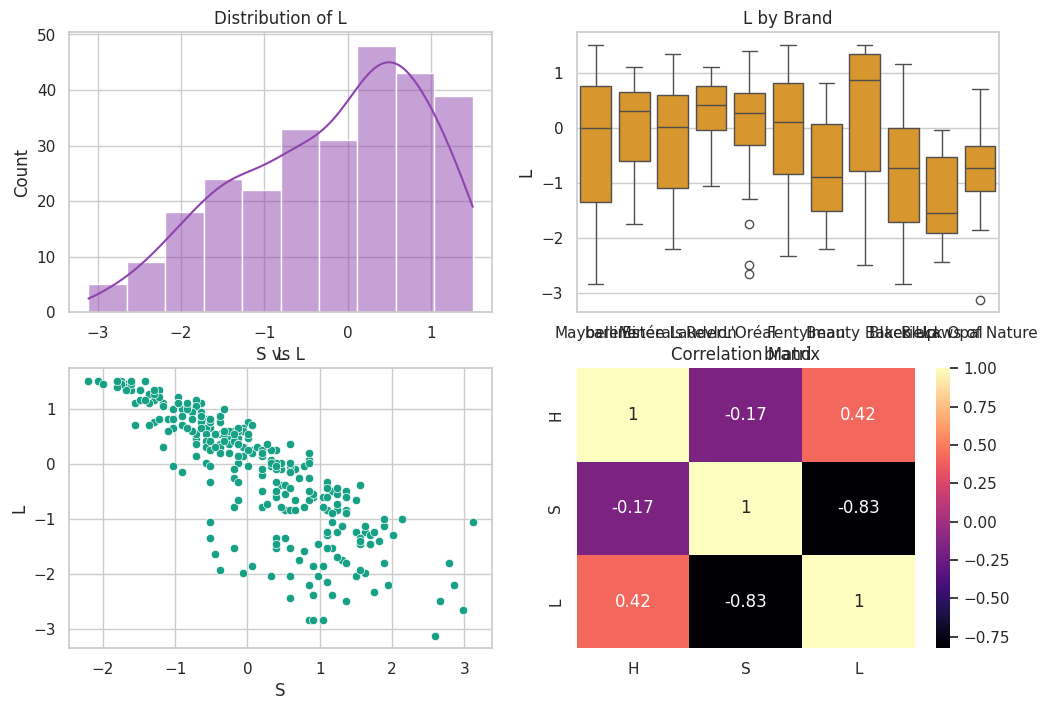

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['L'], kde=True, color="#8E44AD", ax=axes[0,0])
axes[0,0].set_title("Distribution of L")

sns.boxplot(x='brand', y='L', data=df, color="#F39C12", ax=axes[0,1])
axes[0,1].set_title("L by Brand")

sns.scatterplot(x='S', y='L', data=df, color="#16A085", ax=axes[1,0])
axes[1,0].set_title("S vs L")

sns.heatmap(df[['H','S','L']].corr(),annot=True,cmap="magma",ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")



The dashboard provides a comprehensive overview of the dataset.
The histogram shows that the distribution of L is approximately centered and relatively symmetric, indicating balanced lightness values.
The boxplot reveals noticeable variation in L across brands, suggesting that brand choice influences lightness levels.
The scatter plot demonstrates a clear relationship between saturation (S) and lightness (L), supporting the presence of an interaction between color properties.
Finally, the heatmap confirms the strength and direction of correlations among numerical features, highlighting which variables are most associated with the target